# Introduction
Customer segmentation is a critical component of modern retail analytics. This project utilizes unsupervised machine learning to move beyond demographic assumptions and group customers based on their actual behavior—specifically annual income and spending patterns. By applying K-Means clustering, we transform raw transaction data into actionable business segments, enabling a shift from generic advertising to personalized, data-driven marketing strategies

## Imports and Data Loading

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Load dataset
df = pd.read_csv('Mall_Customers.csv')
# Select relevant features (Annual Income and Spending Score)
X = df.iloc[:, [3, 4]].values 

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## Exploratory Data Analysis (EDA)

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Genre                   200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB

Descriptive Statistics:
       CustomerID         Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000  200.000000          200.000000              200.000000
mean   100.500000   38.850000           60.560000               50.200000
std     57.879185   13.969007           26.264721               25.823522
min      1.000000   18.000000           15.000000                1.000000
25%     50.750000   28.750000           41.500000               34.750000
50%    100.500000   3

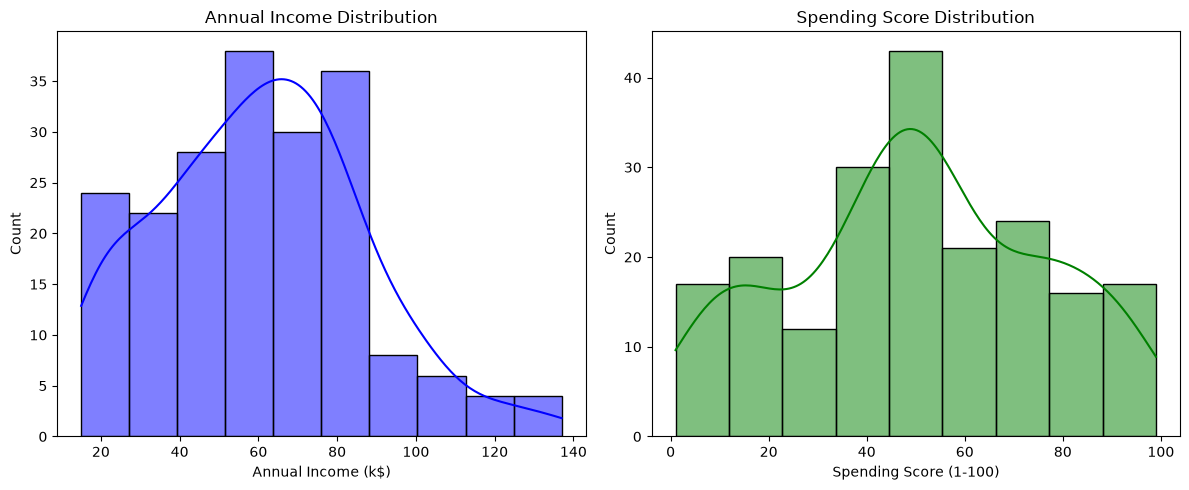

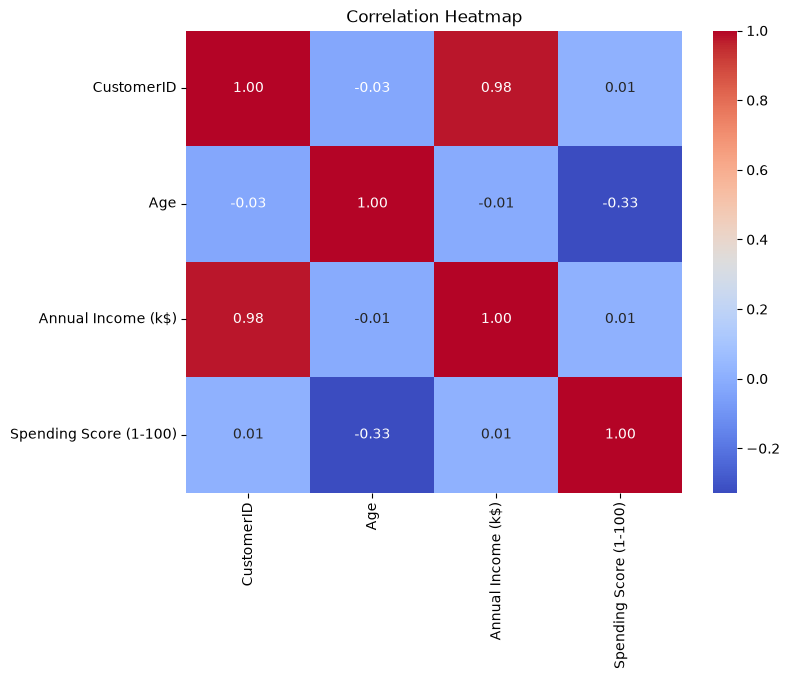

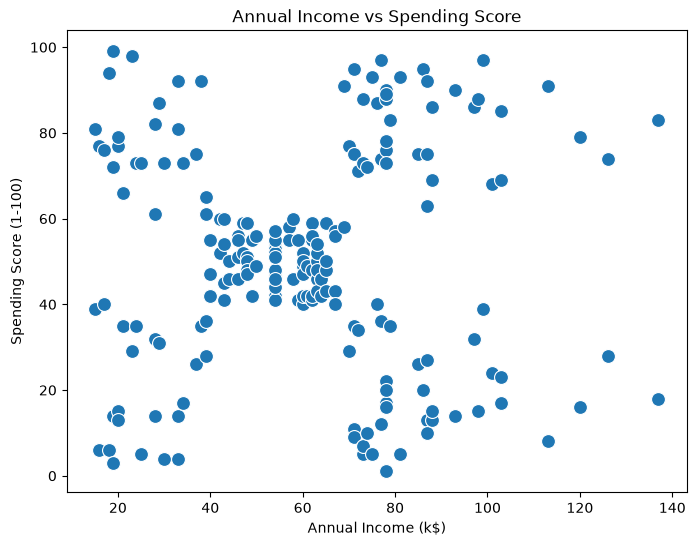

In [5]:
# 1. Basic statistics check
print("Dataset Info:")
df.info()
print("\nDescriptive Statistics:")
print(df.describe())

# 2. Distribution Plot for Income and Spending Score
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['Annual Income (k$)'], kde=True, color='blue')
plt.title('Annual Income Distribution')

plt.subplot(1, 2, 2)
sns.histplot(df['Spending Score (1-100)'], kde=True, color='green')
plt.title('Spending Score Distribution')

plt.tight_layout()
plt.show()

# 3. Correlation Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

# 4. Bivariate Analysis (Scatter Plot)
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='Annual Income (k$)', y='Spending Score (1-100)', s=100)
plt.title('Annual Income vs Spending Score')
plt.show()

## Elbow Method to determine optimal clusters

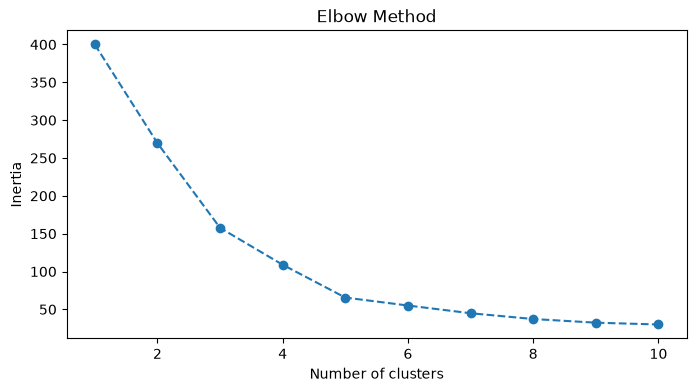

In [4]:
inertia = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(range(1, 11), inertia, marker='o', linestyle='--')
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.show()

## Applying K-Means and PCA Visualization

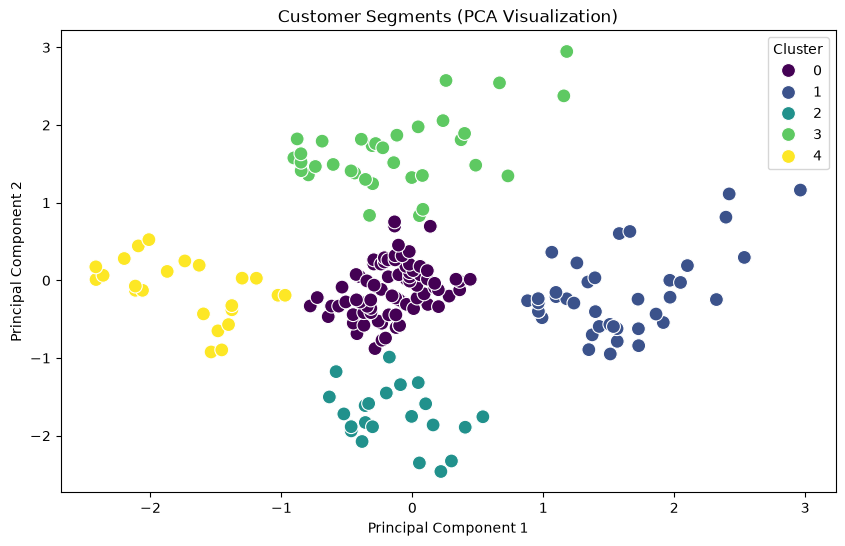

In [7]:
# Apply K-Means (Replace n_clusters with the value observed from Elbow plot)
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42, n_init=10)
y_kmeans = kmeans.fit_predict(X_scaled)

# Apply PCA for dimensionality reduction
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Visualize
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y_kmeans, palette='viridis', s=100)
plt.title('Customer Segments (PCA Visualization)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.show()

## Generating Segment Insights (Business Logic)

In [8]:
# Add cluster labels back to the original dataframe
df['Cluster'] = y_kmeans

# Calculate mean values for each cluster to support marketing strategies
cluster_summary = df.groupby('Cluster')[['Annual Income (k$)', 'Spending Score (1-100)']].mean()
print("Cluster Analysis Summary:")
print(cluster_summary)

Cluster Analysis Summary:
         Annual Income (k$)  Spending Score (1-100)
Cluster                                            
0                 55.296296               49.518519
1                 86.538462               82.128205
2                 25.727273               79.363636
3                 88.200000               17.114286
4                 26.304348               20.913043


## Interpretation
Based on the Cluster Analysis Summary, we can define the following archetypes:

Cluster 1 & 3 (High Income): These segments represent the high-value bracket. Cluster 1 shows high spending, while Cluster 3 shows low spending, suggesting "Luxury Enthusiasts" versus "High-Income Savers."

Cluster 2 (Low Income, High Spending): These are "Targeted Shoppers" who spend significantly despite lower income, indicating high brand loyalty or impulsive shopping behavior.

Cluster 0 (Mid-Range): The "Standard Customer" segment with balanced income and spending patterns, forming the core of the business base.

Cluster 4 (Low Income, Low Spending): The "Budget-Conscious" segment, requiring cost-effective promotions and value-based marketing.

## Conclusion
The analysis successfully segmented the mall customer base into five distinct profiles, validated by clear separation in the PCA visualization. By identifying the unique characteristics of each cluster, the business can optimize marketing ROI by targeting high-spending segments with premium offerings and budget-conscious segments with loyalty-building discounts. This pipeline provides a scalable foundation for any future customer-centric business strategy.